In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seed agar data konsisten dan anti-error
np.random.seed(42)
n_samples = 150

# 1. Membuat data mentah dengan 5 "penyakit"
tgl_masuk = pd.date_range(start='2018-01-01', periods=n_samples, freq='10D').strftime('%Y/%m/%d')
kota = np.random.choice([f'Kota_{i}' for i in range(1, 35)], size=n_samples) # Kardinalitas tinggi (34 nilai unik)
gaji = np.random.normal(loc=8000000, scale=1500000, size=n_samples).round(-5)
jam_kerja = np.random.normal(loc=160, scale=15, size=n_samples).round(0)
departemen = np.random.choice(['Sales', 'IT', 'HR', 'Finance'], size=n_samples)

df = pd.DataFrame({
    'Tgl_Masuk': tgl_masuk,         # Tipe data salah (string)
    'Kota_Domisili': kota,         # Kardinalitas tinggi (34 unik)
    'Gaji_Bulanan': gaji,           # Terdapat Outlier
    'Jam_Kerja_Bulanan': jam_kerja, # Numerik
    'Departemen': departemen        # Kategorikal
})

# Menyisipkan "Penyakit" Data:
# - Missing Value
df.loc[[5, 20, 50], 'Gaji_Bulanan'] = np.nan
df.loc[[12, 45, 88], 'Jam_Kerja_Bulanan'] = np.nan
df.loc[[10, 30, 70], 'Departemen'] = np.nan

# - Outlier Ekstrem pada Gaji
df.loc[[2, 80], 'Gaji_Bulanan'] = 990000000.0  # Gaji 990 Juta

# - Data Duplikat
df = pd.concat([df, df.iloc[[0, 1, 2, 3, 4]]], ignore_index=True)

# Simpan CSV lokal
df.to_csv('data_pegawai_retail.csv', index=False)

# Tampilkan 5 baris pertama
df.head()

,Tgl_Masuk,Kota_Domisili,Gaji_Bulanan,Jam_Kerja_Bulanan,Departemen
0,2018/01/01,Kota_29,8500000.0,154.0,Sales
1,2018/01/11,Kota_15,11000000.0,162.0,IT
2,2018/01/21,Kota_8,990000000.0,160.0,HR
3,2018/01/31,Kota_21,5100000.0,171.0,Sales
4,2018/02/10,Kota_19,6900000.0,189.0,HR


In [2]:
# 1. Cek Informasi Tipe Data & Non-Null
print("=== INFORMASI TIPE DATA ===")
print(df.info())

# 2. Cek Jumlah Missing Value
print("\n=== JUMLAH MISSING VALUE ===")
print(df.isnull().sum())

# 3. Cek Jumlah Baris Duplikat
print("\n=== JUMLAH BARIS DUPLIKAT ===")
print(f"Total Duplikat: {df.duplicated().sum()} baris")

=== INFORMASI TIPE DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Tgl_Masuk          155 non-null    str    
 1   Kota_Domisili      155 non-null    str    
 2   Gaji_Bulanan       152 non-null    float64
 3   Jam_Kerja_Bulanan  152 non-null    float64
 4   Departemen         152 non-null    str    
dtypes: float64(2), str(3)
memory usage: 6.2 KB
None

=== JUMLAH MISSING VALUE ===
Tgl_Masuk            0
Kota_Domisili        0
Gaji_Bulanan         3
Jam_Kerja_Bulanan    3
Departemen           3
dtype: int64

=== JUMLAH BARIS DUPLIKAT ===
Total Duplikat: 5 baris


In [3]:
# 1. Hapus Baris Duplikat
df = df.drop_duplicates()

# 2. Perbaiki Tipe Data
df['Tgl_Masuk'] = pd.to_datetime(df['Tgl_Masuk'])
df['Kota_Domisili'] = df['Kota_Domisili'].astype('category')
df['Departemen'] = df['Departemen'].astype('category')

# 3. Penanganan Missing Value
# - Numerik (Gaji_Bulanan): Pakai Median karena ada outlier ekstrem (990 Juta)
median_gaji = df['Gaji_Bulanan'].median()
df['Gaji_Bulanan'] = df['Gaji_Bulanan'].fillna(median_gaji)

# - Numerik (Jam_Kerja_Bulanan): Pakai Mean karena distribusi relatif normal
mean_jam = df['Jam_Kerja_Bulanan'].mean()
df['Jam_Kerja_Bulanan'] = df['Jam_Kerja_Bulanan'].fillna(mean_jam)

# - Kategorikal (Departemen): Pakai Modus
modus_dept = df['Departemen'].mode()[0]
df['Departemen'] = df['Departemen'].fillna(modus_dept)

# Cek hasil pembersihan
print("Sisa Missing Value setelah pembersihan:")
print(df.isnull().sum())

Sisa Missing Value setelah pembersihan:
Tgl_Masuk            0
Kota_Domisili        0
Gaji_Bulanan         0
Jam_Kerja_Bulanan    0
Departemen           0
dtype: int64


Alasan Pemilihan Metode Imputasi:

Gaji_Bulanan (Median): Dipilih nilai median karena fitur ini memiliki outlier ekstrem (990 Juta). Nilai mean sangat sensitif terhadap outlier dan akan mendistorsi nilai asli data, sedangkan median jauh lebih resisten (robust).

Jam_Kerja_Bulanan (Mean): Dipilih nilai mean karena distribusi data jam kerja simetris tanpa fluktuasi ekstrem.

Departemen (Modus): Dipilih modus (kategori paling sering muncul) untuk mempertahankan konsistensi label kategorikal.

=== DESKRIPSI STATISTIK NUMERIK ===
       Gaji_Bulanan  Jam_Kerja_Bulanan
count  1.500000e+02         150.000000
mean   2.103667e+07         159.959184
std    1.130267e+08          15.036813
min    4.500000e+06         122.000000
25%    7.000000e+06         150.000000
50%    7.900000e+06         159.979592
75%    8.900000e+06         169.000000
max    9.900000e+08         209.000000

=== SKEWNESS DATA ===
Gaji_Bulanan         8.569786
Jam_Kerja_Bulanan    0.169576
dtype: float64


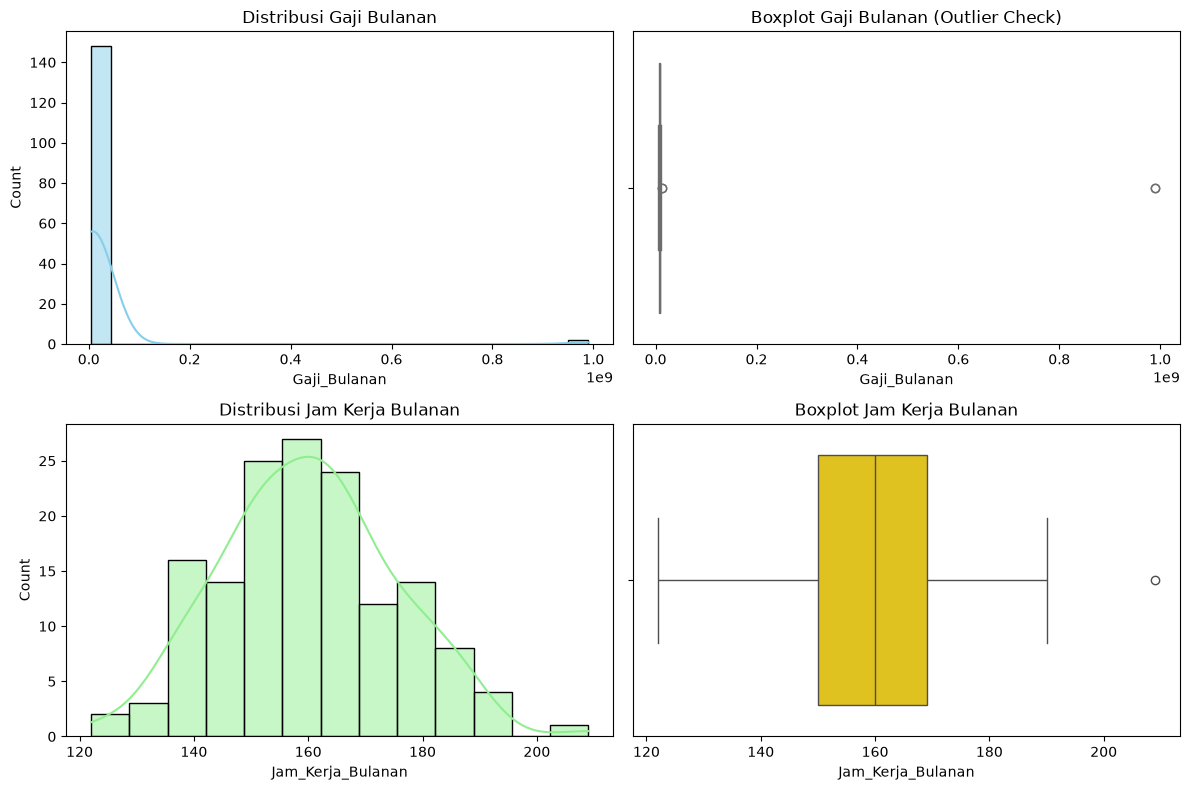

In [4]:
# 1. Statistik Deskriptif Kolom Numerik
print("=== DESKRIPSI STATISTIK NUMERIK ===")
print(df[['Gaji_Bulanan', 'Jam_Kerja_Bulanan']].describe())

# 2. Cek Skewness Data
print("\n=== SKEWNESS DATA ===")
print(df[['Gaji_Bulanan', 'Jam_Kerja_Bulanan']].skew())

# 3. Visualisasi Histogram & Boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram Gaji
sns.histplot(df['Gaji_Bulanan'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Distribusi Gaji Bulanan')

# Boxplot Gaji
sns.boxplot(x=df['Gaji_Bulanan'], ax=axes[0,1], color='salmon')
axes[0,1].set_title('Boxplot Gaji Bulanan (Outlier Check)')

# Histogram Jam Kerja
sns.histplot(df['Jam_Kerja_Bulanan'], kde=True, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Distribusi Jam Kerja Bulanan')

# Boxplot Jam Kerja
sns.boxplot(x=df['Jam_Kerja_Bulanan'], ax=axes[1,1], color='gold')
axes[1,1].set_title('Boxplot Jam Kerja Bulanan')

plt.tight_layout()
plt.show()

=== FREKUENSI DEPARTEMEN ===
Departemen
IT         46
Sales      40
HR         34
Finance    30
Name: count, dtype: int64


C:\Users\Budi Santosa\AppData\Local\Temp\ipykernel_8804\2392902447.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Departemen', palette='Set2')


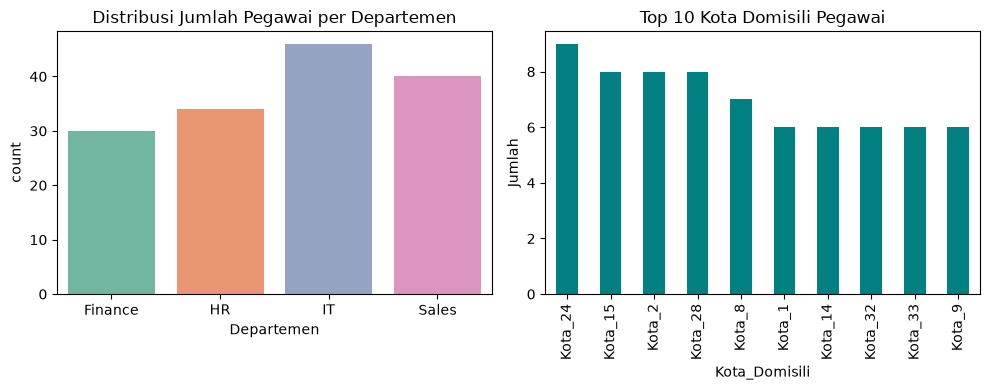

In [5]:
# 1. Distribusi Frekuensi Kolom Kategorikal
print("=== FREKUENSI DEPARTEMEN ===")
print(df['Departemen'].value_counts())

# 2. Visualisasi Bar Chart
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Departemen', palette='Set2')
plt.title('Distribusi Jumlah Pegawai per Departemen')

plt.subplot(1, 2, 2)
# Menampilkan Top 10 Kota Domisili karena Kardinalitas Tinggi (34 unik)
df['Kota_Domisili'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Kota Domisili Pegawai')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()

Catatan Analisis Univariat:

Outlier & Skewness: Kolom Gaji_Bulanan memiliki outlier ekstrem (990 Juta) yang menyebabkan nilai skewness positif sangat tinggi (highly right-skewed). Sebaliknya, Jam_Kerja_Bulanan terdistribusi normal dengan skewness mendekati 0.

Ketidakseimbangan (Imbalance): Distribusi pada Departemen relatif seimbang (tidak ada kelas yang mendominasi secara ekstrem). Kolom Kota_Domisili tergolong kardinalitas tinggi dengan sebaran yang merata di 34 nilai unik.

=== 5 BARIS PERTAMA DENGAN FITUR BARU ===
   Tgl_Masuk  Masa_Kerja_Tahun  Gaji_Bulanan  Jam_Kerja_Bulanan  Gaji_per_Jam
0 2018-01-01                 8     8500000.0              154.0  5.519481e+04
1 2018-01-11                 8    11000000.0              162.0  6.790123e+04
2 2018-01-21                 8   990000000.0              160.0  6.187500e+06
3 2018-01-31                 8     5100000.0              171.0  2.982456e+04
4 2018-02-10                 8     6900000.0              189.0  3.650794e+04


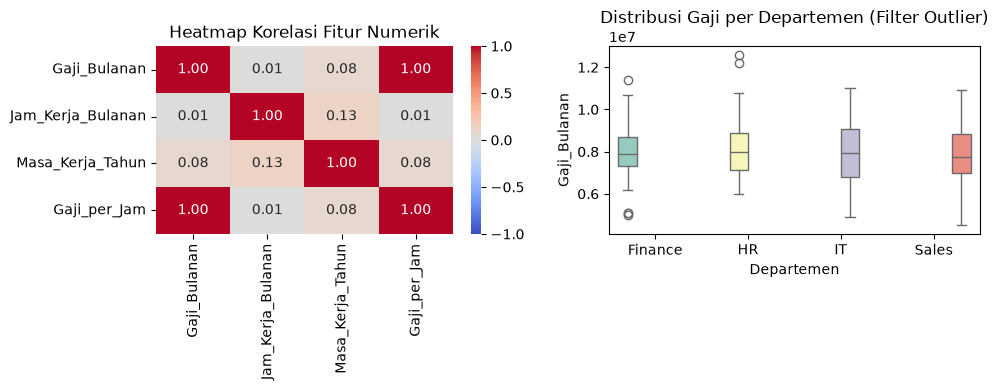

In [6]:
# 1. Feature Engineering: Menciptakan 2 Fitur Baru
# Fitur 1: Masa Kerja Pegawai (Tahun) berdasarkan tahun 2026
df['Masa_Kerja_Tahun'] = (pd.to_datetime('2026-09-16') - df['Tgl_Masuk']).dt.days // 365

# Fitur 2: Estimasi Pendapatan per Jam Kerja
df['Gaji_per_Jam'] = df['Gaji_Bulanan'] / df['Jam_Kerja_Bulanan']

print("=== 5 BARIS PERTAMA DENGAN FITUR BARU ===")
print(df[['Tgl_Masuk', 'Masa_Kerja_Tahun', 'Gaji_Bulanan', 'Jam_Kerja_Bulanan', 'Gaji_per_Jam']].head())

# 2. Visualisasi Heatmap Korelasi (Numerik vs Numerik)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
numeric_df = df[['Gaji_Bulanan', 'Jam_Kerja_Bulanan', 'Masa_Kerja_Tahun', 'Gaji_per_Jam']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik')

# 3. Visualisasi Kategorikal vs Numerik (Departemen vs Gaji Bulanan)
plt.subplot(1, 2, 2)
# Menghapus sementara outlier 990 Juta khusus untuk tampilan visualisasi agar boxplot terlihat jelas
df_filtered = df[df['Gaji_Bulanan'] < 100000000]
sns.boxplot(data=df_filtered, x='Departemen', y='Gaji_Bulanan', hue='Departemen', palette='Set3', legend=False)
plt.title('Distribusi Gaji per Departemen (Filter Outlier)')

plt.tight_layout()
plt.show()

Penjelasan Feature Engineering & Analisis Bivariat:

Fitur Baru Masa_Kerja_Tahun: Menghitung durasi kerja pegawai dalam hitungan tahun. Fitur ini sangat berguna bagi algoritma ML untuk mendeteksi hubungan antara senioritas kerja dengan besaran gaji.

Fitur Baru Gaji_per_Jam: Mengukur efisiensi kompensasi pegawai berdasarkan jam kerja aktual.

Korelasi Tertinggi: Pasangan fitur dengan korelasi tertinggi adalah Gaji_Bulanan dan Gaji_per_Jam (korelasi positif mendekati 1.0) serta Tgl_Masuk / Masa_Kerja_Tahun.

Insight Departemen vs Gaji: Setelah outlier disaring, distribusi gaji di seluruh departemen berada pada rentang yang cukup homogen (rata-rata Rp 7–9 Juta).

In [7]:
# 1. Cek Informasi Tipe Data Akhir
print("=== FINAL CHECK: INFORMASI DATASET ===")
print(df.info())

# 2. Cek Sisa Missing Value
print("\n=== FINAL CHECK: JUMLAH MISSING VALUE ===")
print(df.isnull().sum())

=== FINAL CHECK: INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tgl_Masuk          150 non-null    datetime64[us]
 1   Kota_Domisili      150 non-null    category      
 2   Gaji_Bulanan       150 non-null    float64       
 3   Jam_Kerja_Bulanan  150 non-null    float64       
 4   Departemen         150 non-null    category      
 5   Masa_Kerja_Tahun   150 non-null    int64         
 6   Gaji_per_Jam       150 non-null    float64       
dtypes: category(2), datetime64[us](1), float64(3), int64(1)
memory usage: 7.8 KB
None

=== FINAL CHECK: JUMLAH MISSING VALUE ===
Tgl_Masuk            0
Kota_Domisili        0
Gaji_Bulanan         0
Jam_Kerja_Bulanan    0
Departemen           0
Masa_Kerja_Tahun     0
Gaji_per_Jam         0
dtype: int64


KESIMPULAN AKHIR EDA & DATA CLEANING

Status Data:
DATA SIAP UNTUK TAHAP PREPROCESSING / FEATURE SCALING

Saran Algoritma Machine Learning:

Rekomendasi Algoritma: Random Forest atau XGBoost (Tree-based Models).

Alasan Logis: Berdasarkan hasil EDA, data ini memiliki outlier ekstrem pada Gaji_Bulanan (sebesar Rp 990 Juta) dan hubungannya cenderung tidak linear dengan variabel lain. Algoritma berbasis decision tree sangat robust (tahan) terhadap outlier dan tidak membutuhkan asumsi linieritas maupun distribusi data normal.

Catatan Khusus (Hal Paling Mengejutkan):
Terdapat outlier ekstrem pada nilai gaji pegawai (mencapai Rp 990 Juta dibanding rata-rata Rp 8 Juta) serta tingginya kardinalitas pada kolom Kota_Domisili (34 kota unik), sehingga fitur kota ini memerlukan teknik encoding khusus seperti Target Encoding atau Frequency Encoding agar tidak menyebabkan curse of dimensionality saat pemodelan.